# Phase 5: Failure Analysis and Query-Level Error Taxonomy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

#Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')

#paths
PROJECT_ROOT=Path.cwd().parent
DATA_PROCESSED=PROJECT_ROOT/'data'/'processed'
PHASE4_OUTPUT=DATA_PROCESSED /'phase4_normalization'
PHASE5_OUTPUT=DATA_PROCESSED/'phase5_failure_analysis'
PHASE5_OUTPUT.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Phase 5 output directory: {PHASE5_OUTPUT}")

PIPELINES=['raw', 'global', 'per_query']

Project root: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding
Phase 5 output directory: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\phase5_failure_analysis


# 1. Phase 4 results

In [2]:
print("="*80)
print("LOADING PHASE 4 RESULTS")
print("="*80)

query_metrics_2007={}
predictions_2007={}
query_metrics_2008={}
predictions_2008={}

#Loading MQ2007
print("\nMQ2007:")
for pipeline in PIPELINES:
    qm_file=PHASE4_OUTPUT / f'mq2007_{pipeline}_query_metrics.csv'
    if not qm_file.exists():
        raise RuntimeError(f"Missing required file: {qm_file}")
    query_metrics_2007[pipeline]=pd.read_csv(qm_file)
    print(f"{pipeline:12s} query_metrics: {len(query_metrics_2007[pipeline])} queries")
    
    pred_file=PHASE4_OUTPUT / f'mq2007_{pipeline}_predictions.csv'
    if not pred_file.exists():
        raise RuntimeError(f"Missing required file: {pred_file}")
    predictions_2007[pipeline]=pd.read_csv(pred_file)
    
    #Validating required columns
    required_cols=['qid', 'label', 'score']
    missing=[c for c in required_cols if c not in predictions_2007[pipeline].columns]
    if missing:
        raise RuntimeError(f"MQ2007 {pipeline} predictions missing columns: {missing}")
    print(f"{pipeline:12s} predictions: {len(predictions_2007[pipeline])} documents")

#Loading MQ2008 (PREDICTIONS MANDATORY)
print("\nMQ2008:")
for pipeline in PIPELINES:
    qm_file=PHASE4_OUTPUT/f'mq2008_{pipeline}_query_metrics.csv'
    if not qm_file.exists():
        raise RuntimeError(f"Missing required file: {qm_file}")
    query_metrics_2008[pipeline]=pd.read_csv(qm_file)
    print(f"{pipeline:12s} query_metrics: {len(query_metrics_2008[pipeline])} queries")
    
    pred_file=PHASE4_OUTPUT/f'mq2008_{pipeline}_predictions.csv'
    if not pred_file.exists():
        raise RuntimeError(
            f"Missing MQ2008 prediction files. Re-run Phase 4 saving step to generate mq2008_*_predictions.csv. "
            f"Missing: {pred_file}"
        )
    predictions_2008[pipeline]=pd.read_csv(pred_file)
    
    #Validating required columns
    required_cols=['qid', 'label', 'score']
    missing=[c for c in required_cols if c not in predictions_2008[pipeline].columns]
    if missing:
        raise RuntimeError(f"MQ2008 {pipeline} predictions missing columns: {missing}")
    print(f"{pipeline:12s} predictions: {len(predictions_2008[pipeline])} documents")

print("\n" + "="*80)
print("ALL PHASE 4 RESULTS LOADED AND VALIDATED")
print("="*80)

LOADING PHASE 4 RESULTS

MQ2007:
raw          query_metrics: 336 queries
raw          predictions: 13652 documents
global       query_metrics: 336 queries
global       predictions: 13652 documents
per_query    query_metrics: 336 queries
per_query    predictions: 13652 documents

MQ2008:
raw          query_metrics: 156 queries
raw          predictions: 2874 documents
global       query_metrics: 156 queries
global       predictions: 2874 documents
per_query    query_metrics: 156 queries
per_query    predictions: 2874 documents

ALL PHASE 4 RESULTS LOADED AND VALIDATED


Failure analysis happens at query level

Tie/ranking analysis happens at document level

# 2. Data-Driven Flat-Score Threshold

In [7]:
print("="*80)
print("DATA-DRIVEN FLAT-SCORE THRESHOLD")
print("="*80)

#Collecting score_std from ALL avoidable failures across ALL pipelines
all_score_stds=[]
pipeline_counts={}

print("\nCollecting calibration samples from MQ2007 avoidable failures:")
for pipeline in PIPELINES:
    qm=query_metrics_2007[pipeline]
    #Avoidable failures: num_relevant_1 > 0 AND Failure@5_primary==True
    avoidable=qm[(qm['num_relevant_1']>0)&(qm['Failure@5_primary']==True)]
    stds=avoidable['score_std_top10'].values
    all_score_stds.extend(stds)
    pipeline_counts[pipeline]=len(stds)
    print(f"{pipeline:12s}:{len(stds):3d} avoidable failures")

all_score_stds=np.array(all_score_stds)

if len(all_score_stds) == 0:
    raise RuntimeError(
        "No calibration samples found for flat-score threshold. "
        "Avoidable failure set is empty; cannot derive data-driven threshold."
    )

stds = avoidable['score_std_top10'].dropna().values


print(f"\nTotal calibration samples: {len(all_score_stds)}")
print(f"\nCombined score_std_top10 distribution:")
print(f"Min:{all_score_stds.min():.4f}")
print(f"10%:{np.percentile(all_score_stds, 10):.4f}")
print(f"25%:{np.percentile(all_score_stds, 25):.4f}")
print(f"50%:{np.percentile(all_score_stds, 50):.4f}")
print(f"75%:{np.percentile(all_score_stds, 75):.4f}")
print(f"Max:{all_score_stds.max():.4f}")

#Setting threshold at 25th percentile
FLAT_SCORE_THRESHOLD=np.percentile(all_score_stds, 25)

print(f"\n{'='*80}")
print(f"SELECTED THRESHOLD: {FLAT_SCORE_THRESHOLD:.4f} (25th percentile)")
print(f"{'='*80}")
print(f"\nThreshold is data-driven and calibrated across pipelines to reduce bias.")

DATA-DRIVEN FLAT-SCORE THRESHOLD

raw         : 44 avoidable failures
global      : 46 avoidable failures
per_query   : 56 avoidable failures

Total calibration samples: 146

Combined score_std_top10 distribution:
Min:0.0082
10%:0.0300
25%:0.0414
50%:0.0546
75%:0.0873
Max:0.2046

SELECTED THRESHOLD: 0.0414 (25th percentile)

Threshold is data-driven and calibrated across pipelines to reduce bias.


We set a flat-score threshold based on real model behavior rather than an arbitrary cutoff. Specifically, we looked at queries where the model failed even though relevant documents were available (avoidable failures) and examined how spread out the top-10 scores were. By pooling these cases across all pipelines and taking the bottom quartile of score separation, we identified a threshold that captures unusually flat rankings. This allows us to distinguish failures caused by weak score separation from failures driven by other factors, without introducing pipeline-specific bias.

**Queries that already failed and have std<=0.0414 are likely failing because the model could not clearly separate documents**

## 2.1 Threshold Sensitivity Check for Different Percentiles


THRESHOLD SENSITIVITY SWEEP

Flat-score failure % by threshold:


pipeline,global,per_query,raw
percentile,,,
10,10.8696,7.1429,13.6364
15,13.0435,17.8571,13.6364
20,17.3913,26.7857,15.9091
25,19.5652,32.1429,22.7273
30,23.9130,37.5000,27.2727
35,30.4348,44.6429,27.2727
40,36.9565,50.0000,31.8182


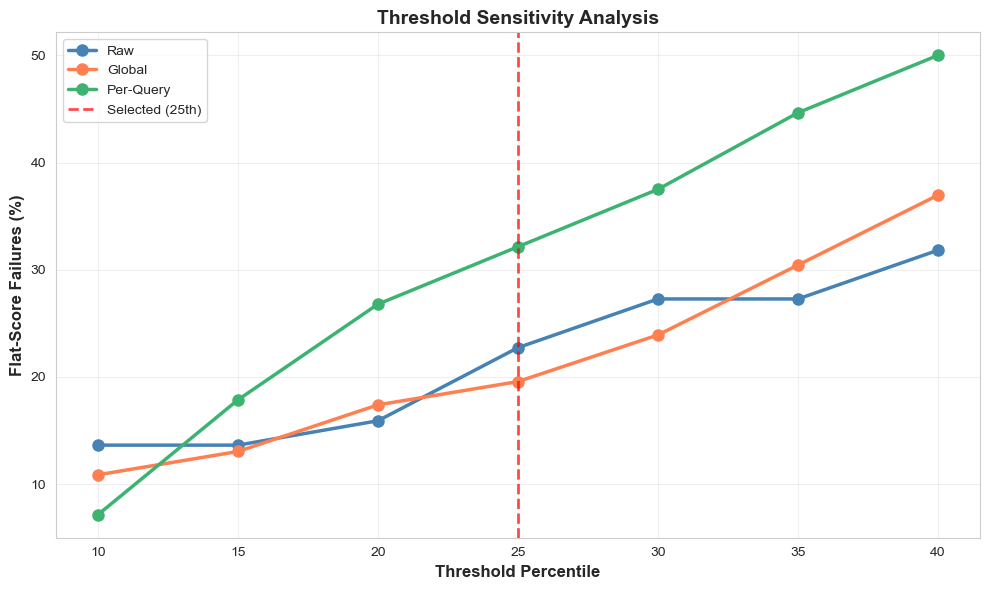


Saved: threshold_sensitivity.png
Saved: threshold_sweep_sensitivity.csv


In [12]:
print("\n"+"="*80)
print("THRESHOLD SENSITIVITY SWEEP")
print("="*80)

percentiles=[10, 15, 20, 25, 30, 35, 40]
threshold_values={p: np.percentile(all_score_stds, p) for p in percentiles}

sweep_results=[]
for p in percentiles:
    threshold=threshold_values[p]
    for pipeline in PIPELINES:
        qm=query_metrics_2007[pipeline]
        avoidable=qm[(qm['num_relevant_1']>0)&(qm['Failure@5_primary']==True)]
        if len(avoidable)>0:
            avoidable['score_std_top10']=avoidable['score_std_top10'].dropna()
            if len(avoidable['score_std_top10']):
                flat_count=(avoidable['score_std_top10']<=threshold).sum()
                flat_pct=100*flat_count/len(avoidable)
                sweep_results.append({
                    'percentile': p,
                    'threshold': threshold,
                    'pipeline': pipeline,
                    'flat_score_count': flat_count,
                    'flat_score_pct': flat_pct
                })

sweep_df=pd.DataFrame(sweep_results)

print("\nFlat-score failure % by threshold:")
display(sweep_df.pivot(index='percentile', columns='pipeline', values='flat_score_pct'))

#Plot
fig, ax=plt.subplots(figsize=(10, 6))
colors={'raw': 'steelblue', 'global': 'coral', 'per_query': 'mediumseagreen'}
for pipeline in PIPELINES:
    data=sweep_df[sweep_df['pipeline']==pipeline]
    ax.plot(data['percentile'], data['flat_score_pct'], 
            marker='o', linewidth=2.5, markersize=8, 
            color=colors[pipeline], label=pipeline.replace('_', '-').title())

ax.axvline(25, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Selected (25th)')
ax.set_xlabel('Threshold Percentile', fontsize=12, fontweight='bold')
ax.set_ylabel('Flat-Score Failures (%)', fontsize=12, fontweight='bold')
ax.set_title('Threshold Sensitivity Analysis', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PHASE5_OUTPUT / 'threshold_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

sweep_df.to_csv(PHASE5_OUTPUT / 'threshold_sweep_sensitivity.csv', index=False)
print(f"\nSaved: threshold_sensitivity.png")
print(f"Saved: threshold_sweep_sensitivity.csv")

We are checking for each pipeline, what fraction of its avoidable failures would be classified as flat-score failures under different threshold choices.

As we increase the percentile, we have more failures as Flat score which is expected. Perquery has the highest flat-score failure % across. We see it as among per-query's avoidable failures, a larger share look "flat-score-like". 

# 3. Failure Taxonomy with Weak-Signal Detection